In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# DEVICE & SEED
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

# ============================================================
# PHYSICAL PARAMETERS
# ============================================================
g = 9.81
L = 20.0
T_end = 5.0
H0 = 1.0

# Bottom topography (matching provided file)
b0, Ab, Lb = 0.5, 0.1, 10.0 

def bottom_profile(x):
    return b0 + Ab * torch.cos(2*np.pi*x/Lb)

def bottom_gradient(x):
    return -Ab * torch.sin(2*np.pi*x/Lb) * (2*np.pi/Lb)

# ============================================================
# PINN MODEL (NON-CONSERVATIVE)
# ============================================================
class PINN_NonCons(nn.Module):
    def __init__(self, layers=[2, 32, 32, 32, 2]):
        super().__init__()
        self.net = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

    def forward(self, xt):
        for layer in self.net[:-1]:
            xt = torch.tanh(layer(xt))
        out = self.net[-1](xt)
        h = torch.nn.functional.softplus(out[:, 0:1]) + 1e-6
        u = out[:, 1:2]
        return h, u

    def residuals(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)
        h, u = self(torch.cat([x, t], 1))
        
        h_t = torch.autograd.grad(h, t, torch.ones_like(h), create_graph=True)[0]
        h_x = torch.autograd.grad(h, x, torch.ones_like(h), create_graph=True)[0]
        u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
        u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
        
        b_x = bottom_gradient(x)
        
        # Non-conservative residuals
        res_mass = h_t + u * h_x + h * u_x
        res_mom  = u_t + u * u_x + g * h_x + g * b_x
        return res_mass, res_mom

# ============================================================
# TRAINING SETUP
# ============================================================
model = PINN_NonCons().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Data Sampling
Nf, Nic = 10000, 1000
x_f = L * torch.rand(Nf, 1).to(device)
t_f = T_end * torch.rand(Nf, 1).to(device)
x_ic = L * torch.rand(Nic, 1).to(device)
t_ic = torch.zeros_like(x_ic)

def get_ic(x):
    Ap, xc, sigma = 0.00, L/2, 0.6
    b = bottom_profile(x)
    h0 = H0 - b + Ap * torch.exp(-(x-xc)**2/(2*sigma**2))
    u0 = torch.zeros_like(x)
    return h0, u0

# Training Loop
for ep in range(3001):
    optimizer.zero_grad()
    
    # PDE Loss
    r_h, r_u = model.residuals(x_f, t_f)
    loss_pde = torch.mean(r_h**2 + r_u**2)
    
    # IC Loss
    h0_target, u0_target = get_ic(x_ic)
    h0_pred, u0_pred = model(torch.cat([x_ic, t_ic], 1))
    loss_ic = torch.mean((h0_pred - h0_target)**2 + (u0_pred - u0_target)**2)
    
    loss = loss_pde + 10 * loss_ic
    loss.backward()
    optimizer.step()
    
    if ep % 500 == 0:
        print(f"Epoch {ep} | Loss: {loss.item():.3e}")

# ============================================================
# ERROR CALCULATION (vs "Exact" Numerical Solution)
# ============================================================

Nx = 400
x_np = np.linspace(0, L, Nx).reshape(-1, 1)
x_test = torch.tensor(x_np, dtype=torch.float32).to(device)
t_test = (T_end * torch.ones_like(x_test)).to(device)

model.eval()
with torch.no_grad():
    h_pred, u_pred = model(torch.cat([x_test, t_test], 1))
    b_test = bottom_profile(x_test)
    eta_pred = (h_pred + b_test).cpu().numpy().flatten()

# Save Elevation to dat file
# np.savetxt("free_surface_noncons.dat", eta_pred, fmt='%.8e')
# print("Non-conservative free surface saved.")

Epoch 0 | Loss: 1.867e+00
Epoch 500 | Loss: 1.385e-01
Epoch 1000 | Loss: 3.153e-02
Epoch 1500 | Loss: 8.912e-03
Epoch 2000 | Loss: 4.976e-03
Epoch 2500 | Loss: 3.966e-03
Epoch 3000 | Loss: 2.390e-03


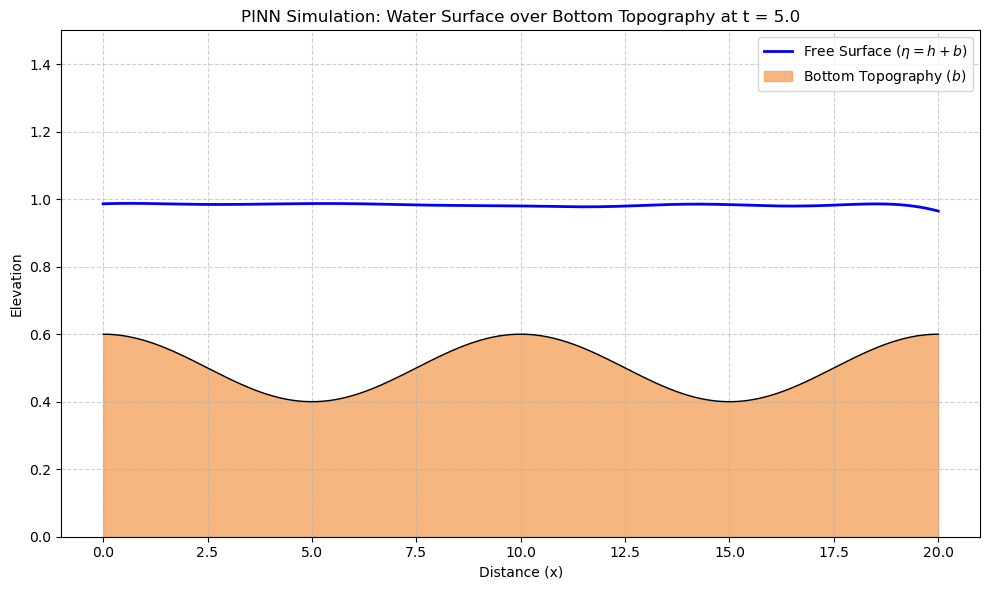

In [5]:
# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
x_plot = np.linspace(0, L, 400)
x_tensor = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1).to(device)
t_final = torch.ones_like(x_tensor) * T_end

model.eval()
with torch.no_grad():
    h_pred, u_pred = model(torch.cat([x_tensor, t_final], 1))
    b_plot = bottom_profile(x_tensor).cpu().numpy().flatten()
    h_plot = h_pred.cpu().numpy().flatten()
    eta_plot = h_plot + b_plot  # Free surface elevation

# 2. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the Free Surface (Water Level)
plt.plot(x_plot, eta_plot, 'b-', linewidth=2, label='Free Surface ($\eta = h + b$)')

# Plot the Bottom Topography (Shaded region)
plt.fill_between(x_plot, 0, b_plot, color='sandybrown', alpha=0.8, label='Bottom Topography ($b$)')
plt.plot(x_plot, b_plot, 'k-', linewidth=1)

# Formatting
plt.title(f'PINN Simulation: Water Surface over Bottom Topography at t = {T_end}')
plt.xlabel('Distance (x)')
plt.ylabel('Elevation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.ylim(0, H0 + 0.5) # Adjust based on your H0

plt.tight_layout()
plt.show()

In [6]:
np.sqrt(((eta_pred-1)**2).mean().item())

np.float64(0.017601706826407323)